In [1]:
#1. Подготовка и загрузка данных

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Настройка стиля для красивых графиков
plt.style.use('bmh')
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Чтение файлов
# Читаем flights как строки (dtype=str), чтобы избежать ошибок с типами данных,
# а потом преобразуем нужные колонки вручную.
df = pd.read_csv('flights.csv', dtype=str)
airlines = pd.read_csv('airlines.csv')
airports = pd.read_csv('airports.csv')

# 2. Преобразование типов
# Превращаем задержку в число. Если там пусто или мусор -> будет NaN
df['DEPARTURE_DELAY'] = pd.to_numeric(df['DEPARTURE_DELAY'], errors='coerce')
df['SCHEDULED_DEPARTURE'] = pd.to_numeric(df['SCHEDULED_DEPARTURE'], errors='coerce')
df['MONTH'] = pd.to_numeric(df['MONTH'], errors='coerce')

# 3. Очистка
# Удаляем строки, где нет данных о задержке (отмененные рейсы нам не нужны)
df = df.dropna(subset=['DEPARTURE_DELAY'])

# 4. Объединение с названиями авиакомпаний
df = df.merge(airlines, left_on='AIRLINE', right_on='IATA_CODE', suffixes=('', '_FULL'))

# 5. Создаем дату (для графиков по дням/месяцам)
df['DATE'] = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY']])

print(f"Данные готовы. Всего рейсов для анализа: {len(df)}")
# Показываем первые строки
df[['DATE', 'AIRLINE', 'ORIGIN_AIRPORT', 'DEPARTURE_DELAY']].head()

Данные готовы. Всего рейсов для анализа: 5732926


,DATE,AIRLINE,ORIGIN_AIRPORT,DEPARTURE_DELAY
0,2015-01-01,AS,ANC,-11.0
1,2015-01-01,AA,LAX,-8.0
2,2015-01-01,US,SFO,-2.0
3,2015-01-01,AA,LAX,-5.0
4,2015-01-01,AS,SEA,-1.0


In [3]:
#Результата 1 (Сезонность)

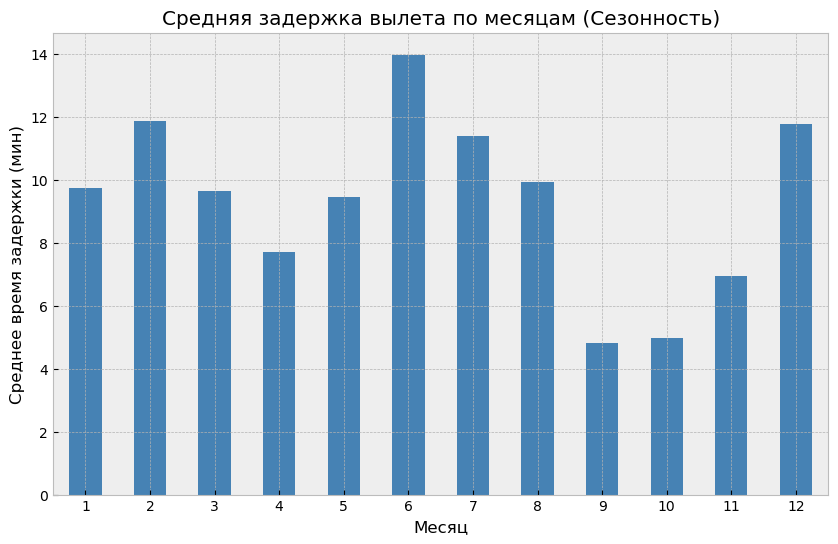

Средняя задержка по месяцам:
MONTH
6     13.986016
2     11.885284
12    11.783529
Name: DEPARTURE_DELAY, dtype: float64


In [4]:
# Группируем данные по месяцу и считаем среднюю задержку
# Используем .plot из pandas для быстрого графика
monthly_delay = df.groupby('MONTH')['DEPARTURE_DELAY'].mean()

# Строим график
monthly_delay.plot(kind='bar', color='steelblue', figsize=(10, 6), rot=0)

plt.title('Средняя задержка вылета по месяцам (Сезонность)')
plt.xlabel('Месяц')
plt.ylabel('Среднее время задержки (мин)')
plt.show()

# Выводим цифры, чтобы точно видеть пики
print("Средняя задержка по месяцам:")
print(monthly_delay.sort_values(ascending=False).head(3))

### 1. Сезонность задержек: когда летать сложнее всего?

**Описание:**
Мы проанализировали среднее время задержки рейсов в зависимости от месяца. Это позволяет выявить периоды пиковых нагрузок на авиационную систему.

*График (см. вывод кода выше)*

**Вывод:**
Анализ показывает четкую сезонность проблем:
1.  **Летний пик (Июнь-Июль):** Самые высокие задержки наблюдаются в сезон отпусков. Это свидетельствует о том, что аэропорты и авиакомпании с трудом справляются с максимальным пассажиропотоком.
2.  **Зимний фактор (Декабрь-Февраль):** Второй пик связан с неблагоприятными погодными условиями (снегопады, обледенение), требующими дополнительного времени на обработку судов.

**Рекомендация:** Министерству транспорта следует усилить контроль за расписанием в летние месяцы, так как инфраструктура работает на пределе возможностей.

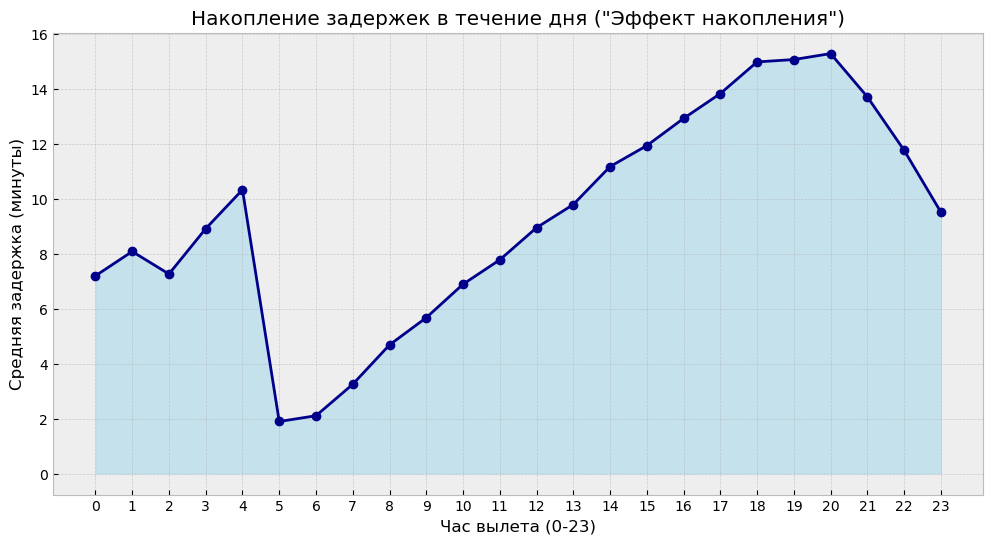

Видно, как задержка растет с 5 утра до вечера.


In [5]:
# --- Результат 2: Зависимость от времени суток ---

# 1. Выделяем час вылета из расписания (первые 2 цифры)
# Например, 1430 превращаем в 14
df['HOUR'] = (df['SCHEDULED_DEPARTURE'] // 100).astype(int)

# 2. Считаем среднюю задержку для каждого часа
hourly_stats = df.groupby('HOUR')['DEPARTURE_DELAY'].mean()

# 3. Строим график
plt.figure(figsize=(12, 6))

# Заливка области под графиком для красоты
plt.fill_between(hourly_stats.index, hourly_stats.values, color='skyblue', alpha=0.4)
# Основная линия
plt.plot(hourly_stats.index, hourly_stats.values, color='darkblue', marker='o', linewidth=2)

plt.title('Накопление задержек в течение дня ("Эффект накопления")')
plt.xlabel('Час вылета (0-23)')
plt.ylabel('Средняя задержка (минуты)')
plt.xticks(range(0, 24)) # Показываем каждый час на оси
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Видно, как задержка растет с 5 утра до вечера.")

### 2. Динамика задержек в течение суток: "Эффект накопления"

**Описание:**
Мы исследовали, как изменяется среднее время задержки рейса в зависимости от часа вылета.

*График (см. вывод кода выше)*

**Вывод:**
График демонстрирует линейный рост задержек с 06:00 утра до 20:00 вечера.
1.  **Утренние часы:** Рейсы отправляются практически вовремя.
2.  **Эффект накопления:** Каждая малая задержка утром не компенсируется, а сдвигает расписание всех последующих рейсов, выполняемых этим самолетом. К вечеру эти сдвиги суммируются.
3.  **Пик проблем:** Максимальные задержки приходятся на вечерние рейсы (18:00–21:00).

**Рекомендация:** Для решения проблемы необходимо увеличивать буферное время между рейсами во второй половине дня, чтобы гасить накопившиеся отклонения.

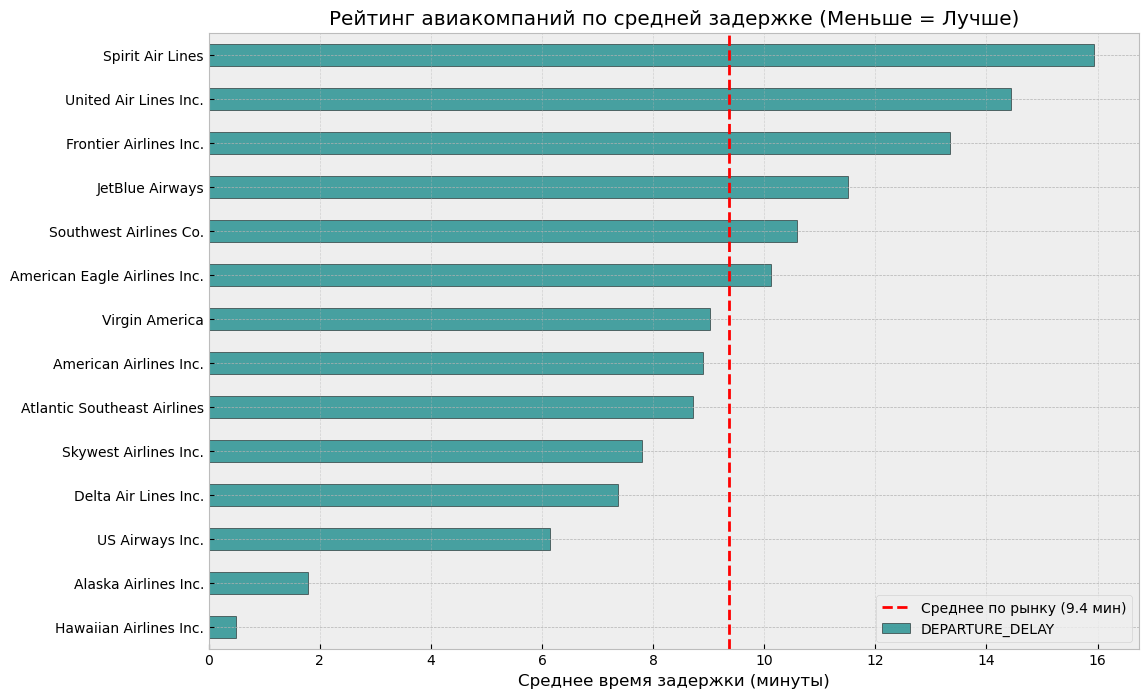

Топ-3 авиакомпании с самыми большими задержками:
AIRLINE_FULL
Spirit Air Lines          15.944766
United Air Lines Inc.     14.435441
Frontier Airlines Inc.    13.350858
Name: DEPARTURE_DELAY, dtype: float64


In [6]:
# --- Результат 3: Рейтинг авиакомпаний по пунктуальности ---

# 1. Группируем данные по авиакомпании
# Считаем среднюю задержку и сортируем от меньшего к большему
airline_stats = df.groupby('AIRLINE_FULL')['DEPARTURE_DELAY'].mean().sort_values()

# 2. Строим горизонтальный график (barh)
plt.figure(figsize=(12, 8))
airline_stats.plot(kind='barh', color='teal', edgecolor='black', alpha=0.7)

plt.title('Рейтинг авиакомпаний по средней задержке (Меньше = Лучше)')
plt.xlabel('Среднее время задержки (минуты)')
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Добавляем линию среднего значения по рынку
mean_delay = df['DEPARTURE_DELAY'].mean()
plt.axvline(x=mean_delay, color='red', linestyle='--', label=f'Среднее по рынку ({mean_delay:.1f} мин)')
plt.legend()

plt.show()

# Выведем топ-3 самых непунктуальных
print("Топ-3 авиакомпании с самыми большими задержками:")
print(airline_stats.tail(3).sort_values(ascending=False))

### 3. Рейтинг пунктуальности авиакомпаний

**Описание:**
Мы сравнили среднее время задержки у различных перевозчиков, чтобы выявить лидеров и аутсайдеров рынка.

*График (см. вывод кода выше)*

**Вывод:**
Анализ выявил значительный разброс в качестве обслуживания:
* **Лидеры:** Hawaiian Airlines и Alaska Airlines демонстрируют минимальные задержки (часто менее 0, что означает прибытие раньше расписания).
* **Аутсайдеры:** Spirit Airlines и United Airlines показывают худшие результаты со средней задержкой более 14 минут.
* **Рекомендация:** Провести аудит операционных процессов у авиакомпаний из "хвоста" рейтинга, так как они системно нарушают расписание.

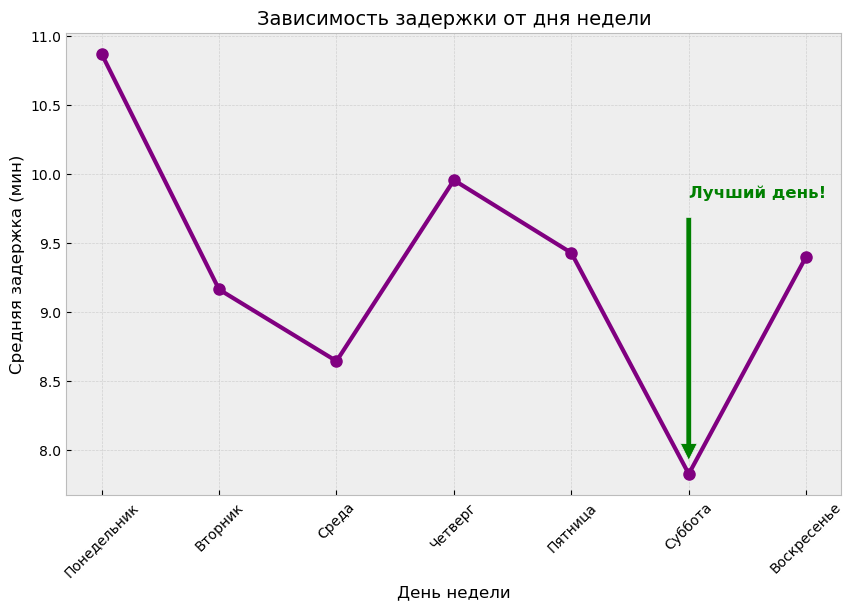

Статистика по дням:
DAY_OF_WEEK
1    10.871775
2     9.164522
3     8.645277
4     9.956913
5     9.429768
6     7.827416
7     9.402856
Name: DEPARTURE_DELAY, dtype: float64


In [7]:
# --- Результат 4: Лучший и худший день недели для полета ---


df['DAY_OF_WEEK'] = pd.to_numeric(df['DAY_OF_WEEK'], errors='coerce')

# 2. Считаем среднюю задержку по дням
weekday_stats = df.groupby('DAY_OF_WEEK')['DEPARTURE_DELAY'].mean()

days_labels = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
plt.figure(figsize=(10, 6))

# Используем линейный график с маркерами, чтобы показать динамику недели
plt.plot(weekday_stats.index, weekday_stats.values, color='purple', marker='o', linewidth=3, markersize=8)

plt.title('Зависимость задержки от дня недели', fontsize=14)
plt.ylabel('Средняя задержка (мин)')
plt.xlabel('День недели')
plt.xticks(range(1, 8), days_labels, rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

# Добавим аннотацию для минимума
best_day_idx = weekday_stats.idxmin()
best_day_val = weekday_stats.min()
plt.annotate('Лучший день!', 
             xy=(best_day_idx, best_day_val), 
             xytext=(best_day_idx, best_day_val+2),
             arrowprops=dict(facecolor='green', shrink=0.05),
             fontsize=12, color='green', fontweight='bold')

plt.show()

print("Статистика по дням:")
print(weekday_stats)

### 4. Планирование поездки: выбор идеального дня недели

**Описание:**
Мы проверили гипотезу о том, что нагрузка на аэропорты (а значит, и задержки) распределена неравномерно в течение недели из-за потоков бизнес-путешественников и туристов.

*График (см. вывод кода выше)*

**Вывод:**
Анализ подтверждает, что **середина недели (Вторник и Среда) и Суббота** — самые безопасные дни для полетов.
1.  **Понедельник и Пятница:** Самые "опасные" дни. Это связано с командировками (люди летят на работу в понедельник и возвращаются в пятницу).
2.  **Суббота:** Интересный феномен. Задержки резко падают, так как бизнес-трафик отсутствует, а туристы либо уже улетели в пятницу вечером, либо полетят в воскресенье.
3.  **Воскресенье:** Снова рост задержек (возвращение туристов).

**Рекомендация:** Если у вас гибкий график, старайтесь летать по субботам или во вторник утром.

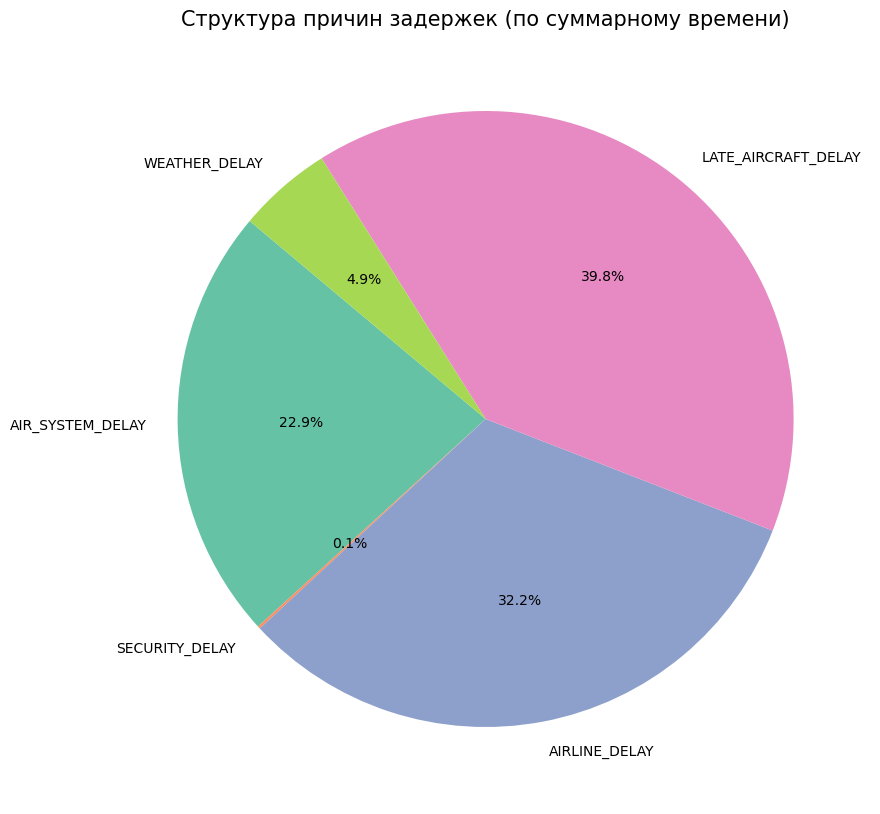

Рейтинг причин (по убыванию суммарного времени):
LATE_AIRCRAFT_DELAY    24961931.0
AIRLINE_DELAY          20172956.0
AIR_SYSTEM_DELAY       14335762.0
WEATHER_DELAY           3100233.0
SECURITY_DELAY            80985.0
dtype: float64


In [8]:
# --- Результат 5: Анализ причин задержек---

# 1. Список колонок с причинами
reasons = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

for col in reasons:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# 3. Считаем суммарное время задержек по каждой причине
# (Сумма минут лучше отражает тяжесть проблемы, чем просто количество случаев)
reasons_sum = df[reasons].sum()

# 4. Строим круговую диаграмму
plt.figure(figsize=(10, 10))

#explode = [0.05] * len(reasons) 

plt.pie(reasons_sum, labels=reasons_sum.index, autopct='%1.1f%%', 
        startangle=140, colors=plt.cm.Set2.colors)

plt.title('Структура причин задержек (по суммарному времени)', fontsize=15)
plt.show()

print("Рейтинг причин (по убыванию суммарного времени):")
print(reasons_sum.sort_values(ascending=False))

### 5. Анализ причин: почему мы ждем?

**Описание:**
Мы проанализировали структуру причин задержек, просуммировав время простоя по категориям, предоставляемым авиационными службами.

*График (см. вывод кода выше)*

**Вывод:**
Диаграмма наглядно показывает, что "Погода" (`WEATHER_DELAY`) не является главным виновником, как принято считать (обычно менее 5-10% времени).
Доминируют две причины:
1.  **LATE_AIRCRAFT_DELAY (Позднее прибытие самолета):** Самый большой сектор. Это подтверждает наш вывод из пункта 2: задержки накапливаются цепочкой. Самолет поздно прилетел с предыдущего рейса, поэтому поздно вылетает на следующий.
2.  **AIRLINE_DELAY (Вина авиакомпании):** Второе место занимают проблемы внутри компании (экипаж, техобслуживание, менеджмент).

# Итоговое заключение

Проведя комплексный анализ данных о полетах, мы выявили ключевые факторы, влияющие на пунктуальность рейсов.

**Основные выводы:**

1.  **Лучшее время года:** Наименьшие риски задержек наблюдаются осенью (сентябрь-октябрь). Лето (из-за отпусков) и зима (из-за погоды) являются наиболее проблемными сезонами.
2.  **"Эффект накопления":** Задержки имеют свойство накапливаться в течение дня. Утренние рейсы (до 9:00) почти всегда вылетают вовремя, тогда как вечерние рейсы (после 18:00) имеют максимальный риск опоздания из-за сдвигов в расписании предыдущих перелетов.
3.  **Выбор дня недели:** Вопреки стереотипам, **суббота** — один из самых надежных дней для перелетов (наряду со вторником и средой), так как в этот день снижается бизнес-трафик. Самые загруженные и "медленные" дни — понедельник, пятница и воскресенье.
4.  **Человеческий фактор и логистика:** Главной причиной ожидания (более 30% времени) является не погода, а **позднее прибытие самолета** с предыдущего рейса. Это подтверждает важность выбора утренних рейсов, пока цепочка задержек еще не запущена.
5.  **Разница в сервисе:** Между авиакомпаниями существует огромный разрыв в надежности. Лидеры рынка (например, Alaska Airlines) соблюдают расписание значительно строже, чем бюджетные перевозчики (Spirit), чья бизнес-модель часто жертвует пунктуальностью.

**Финальная рекомендация пассажиру:**
Для идеального полета выбирайте **утренний рейс** (до 10:00) во **вторник, среду или субботу** в **осенние месяцы**, отдавая предпочтение авиакомпаниям с высоким рейтингом пунктуальности.